# SEÇÃO 1: TÍTULO E OBJETIVO
## Estudo de Trade-off: +Segurança da Informação vs -Performance de Rede

**Objetivo:** Analisar o impacto da criptografia (Segurança) nas métricas de fluxo de rede (Performance) utilizando o dataset CIC-VPN2016. O foco é identificar o 'imposto' computacional e de rede — latência e overhead — cobrado pela utilização de VPNs, além de avaliar a eficiência de modelos de IA na detecção desse tráfego.

### 1.1 JUSTIFICATIVA E CONTEXTO
O aumento do trabalho remoto e a necessidade de conexões seguras tornaram as VPNs essenciais. No entanto, a criptografia introduz um *overhead* (sobrecarga) que pode degradar a performance da rede. Este projeto justifica-se pela necessidade de:
- Identificar padrões de tráfego que diferenciem conexões seguras de comuns.
- Quantificar a perda de performance (latência/vazão) ao utilizar túneis criptografados.
- Avaliar se modelos de Machine Learning conseguem detectar tráfego VPN em tempo real com baixo custo computacional.

## SEÇÃO 2: DICIONÁRIO DE DADOS E ENGENHARIA DE ATRIBUTOS

### 2.1 DICIONÁRIO DE DADOS (Features Principais)

| Variável | Descrição |
| :--- | :--- |
| **duration** | Duração total do fluxo de rede em microssegundos. |
| **flowPktsPerSecond** | Taxa de pacotes transmitidos por segundo (vazão de pacotes). |
| **flowBytesPerSecond** | Taxa de bytes transmitidos por segundo (largura de banda utilizada). |
| **mean_fiat** | Tempo médio de inter-chegada de pacotes no sentido direto (Forward Inter-Arrival Time). |
| **mean_biat** | Tempo médio de inter-chegada de pacotes no sentido reverso (Backward Inter-Arrival Time). |
| **traffic_type** | Categoria original do tráfego (Ex: Facebook, Skype, VPN-Skype). |
| **is_vpn** | Variável alvo binária (1 para tráfego VPN, 0 para Não-VPN). |

In [27]:
# SEÇÃO 2: IMPORTAÇÃO DE BIBLIOTECAS
import pandas as pd # Manipulação de dados tabulares
import numpy as np # Operações matemáticas e vetoriais
import matplotlib.pyplot as plt # Visualização de dados
import seaborn as sns # Visualização estatística aprimorada
import time # Medição de tempo de processamento/inferência
from sklearn.model_selection import train_test_split # Divisão de dados
from sklearn.preprocessing import StandardScaler # Normalização
from sklearn.linear_model import LogisticRegression # Modelo baseline rápido
from sklearn.ensemble import RandomForestClassifier # Modelo complexo de alta performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix # Métricas de avaliação

# Configurações globais para os gráficos
%matplotlib inline
sns.set(style='whitegrid')
print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## SEÇÃO 3: CARREGAMENTO E EXPLORAÇÃO INICIAL
Nesta etapa, baixamos o dataset oficial do Kaggle e verificamos a estrutura bruta dos dados.

In [28]:
import kagglehub
import os

# Realiza o download automático do dataset CIC-VPN2016 via API do KaggleHub
print('Iniciando download do dataset oficial via KaggleHub...')
path = kagglehub.dataset_download('noobbcoder2/vpn-and-non-vpn-application-traffic-cic-vpn2016')
print('Caminho do dataset:', path)

# Lista os arquivos disponíveis no diretório baixado para identificar o CSV
files = [f for f in os.listdir(path) if f.endswith('.csv')]
print('Arquivos encontrados:', files)

# Carrega o primeiro arquivo CSV encontrado em um DataFrame pandas
csv_path = os.path.join(path, files[0])
df = pd.read_csv(csv_path)

# Exibe as primeiras 5 linhas para inspeção visual inicial
print('--- Visualização das primeiras linhas (DADOS REAIS) ---')
display(df.head())

# Exibe o formato (linhas/colunas) e os tipos de dados das colunas
print('\n--- Informações Estruturais ---')
print(f'Shape: {df.shape}')
print(df.info())

# Verifica se existem valores faltantes em cada coluna
print('\n--- Verificação de Valores Nulos ---')
print(df.isnull().sum())

Iniciando download do dataset oficial via KaggleHub...
Using Colab cache for faster access to the 'vpn-and-non-vpn-application-traffic-cic-vpn2016' dataset.
Caminho do dataset: /kaggle/input/vpn-and-non-vpn-application-traffic-cic-vpn2016
Arquivos encontrados: ['consolidated_traffic_data.csv']
--- Visualização das primeiras linhas (DADOS REAIS) ---


,duration,total_fiat,total_biat,min_fiat,min_biat,max_fiat,max_biat,mean_fiat,mean_biat,flowPktsPerSecond,...,std_flowiat,min_active,mean_active,max_active,std_active,min_idle,mean_idle,max_idle,std_idle,traffic_type
0,119994459.0,119994459.0,119970125.0,0.0,0.0,1399330.0,1211310.0,2348.136257,513.267526,2373.792943,...,9107.759178,1753114.0,11300000.0,39438693.0,1.600000e+07,1014624.0,1139537.6,1208289.0,74997.385381,BROWSING
1,143704195.0,143704195.0,42106019.0,0.0,0.0,101572528.0,854818.0,6986.105737,636.898837,603.204381,...,345078.175888,143704195.0,144000000.0,143704195.0,0.000000e+00,101572528.0,102000000.0,101572528.0,0.000000,BROWSING
2,119994980.0,119994980.0,119966891.0,7.0,0.0,819852.0,819602.0,10201.919742,2341.411304,525.030297,...,17736.017265,-1.0,0.0,-1.0,0.000000e+00,-1.0,0.0,-1.0,0.000000,BROWSING
3,119292282.0,119292282.0,119260024.0,3.0,0.0,912990.0,866900.0,11947.148923,3354.712349,381.726288,...,24218.472201,-1.0,0.0,-1.0,0.000000e+00,-1.0,0.0,-1.0,0.000000,BROWSING
4,119772966.0,119772917.0,119772939.0,4.0,0.0,2894671.0,2923147.0,18210.873803,3644.280989,329.331412,...,31326.437353,2210292.0,8688035.0,15165778.0,9.160912e+06,1799762.0,2347216.5,2894671.0,774217.578682,BROWSING



--- Informações Estruturais ---
Shape: (59706, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59706 entries, 0 to 59705
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   duration            59706 non-null  float64
 1   total_fiat          59706 non-null  float64
 2   total_biat          59706 non-null  float64
 3   min_fiat            59706 non-null  float64
 4   min_biat            59706 non-null  float64
 5   max_fiat            59706 non-null  float64
 6   max_biat            59706 non-null  float64
 7   mean_fiat           59706 non-null  float64
 8   mean_biat           59706 non-null  float64
 9   flowPktsPerSecond   59706 non-null  float64
 10  flowBytesPerSecond  59706 non-null  float64
 11  min_flowiat         59706 non-null  float64
 12  max_flowiat         59706 non-null  float64
 13  mean_flowiat        59706 non-null  float64
 14  std_flowiat         59706 non-null  float64
 15  m

In [ ]:
import numpy as np

# Pré-processamento inicial: Limpeza de valores nulos e infinitos
# Criando df_clean antes de qualquer análise estatística
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df_clean = df.dropna().copy()

print(f'DataFrame limpo (df_clean) criado com sucesso. Shape: {df_clean.shape}')

DataFrame limpo (df_clean) criado com sucesso. Shape: (59706, 24)


### 3.1 TRATAMENTO DE VALORES AUSENTES E INFINITOS
Criando o dataset `df_clean` para garantir a integridade das análises subsequentes.

## SEÇÃO 4: ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
Visualizações para entender a distribuição das classes e a correlação entre performance de rede e o uso de VPN.

In [ ]:
# Resumo estatístico para atender ao critério de 'Descrição dos Dados'
display(df_clean.describe())

,duration,total_fiat,total_biat,min_fiat,min_biat,max_fiat,max_biat,mean_fiat,mean_biat,flowPktsPerSecond,...,mean_flowiat,std_flowiat,min_active,mean_active,max_active,std_active,min_idle,mean_idle,max_idle,std_idle
count,5.970600e+04,5.970600e+04,5.970600e+04,5.970600e+04,5.970600e+04,5.970600e+04,5.970600e+04,5.970600e+04,5.970600e+04,5.970600e+04,...,5.970600e+04,5.970600e+04,5.970600e+04,5.970600e+04,5.970600e+04,5.970600e+04,5.970600e+04,5.970600e+04,5.970600e+04,5.970600e+04
mean,2.354579e+07,2.215066e+07,2.049105e+07,2.044648e+06,1.779203e+06,9.063199e+06,7.591169e+06,3.190482e+06,2.776105e+06,4.035707e+03,...,1.461036e+06,2.984009e+06,7.581064e+06,8.795202e+06,1.032545e+07,1.463446e+06,7.285392e+06,8.409731e+06,9.805129e+06,1.360736e+06
std,3.610462e+07,3.465348e+07,2.968948e+07,7.919716e+06,7.455655e+06,2.522047e+07,1.704812e+07,9.150407e+06,8.073066e+06,2.858908e+04,...,4.009995e+06,8.623463e+06,2.605720e+07,2.634682e+07,2.740981e+07,5.432289e+06,2.595500e+07,2.624293e+07,2.724509e+07,5.315973e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00
25%,2.561600e+05,1.116875e+05,2.625000e+03,7.000000e+00,0.000000e+00,2.597200e+04,1.738000e+03,7.927112e+03,3.364451e+02,9.595025e-01,...,9.572403e+03,5.494749e+03,-1.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00
50%,1.306654e+07,1.168921e+07,1.028447e+07,6.400000e+01,2.000000e+01,5.371380e+05,3.828470e+05,1.016749e+05,5.391917e+04,8.545710e+00,...,1.174737e+05,1.374637e+05,-1.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00
75%,2.998854e+07,2.993403e+07,2.968528e+07,3.090250e+03,5.037500e+02,9.829409e+06,9.521396e+06,1.071742e+06,9.615569e+05,1.001268e+02,...,7.482076e+05,1.947242e+06,4.956232e+06,8.943174e+06,1.008053e+07,6.858399e+02,4.077253e+06,7.360520e+06,9.999372e+06,5.385290e+02
max,6.465660e+08,6.465660e+08,6.011851e+08,1.199997e+08,1.199996e+08,6.462877e+08,6.001097e+08,1.520000e+08,1.200000e+08,2.000000e+06,...,6.470000e+07,2.040000e+08,6.465660e+08,6.470000e+08,6.465660e+08,1.840000e+08,6.462877e+08,6.460000e+08,6.462877e+08,1.850000e+08


In [ ]:
# Esta célula era redundante e foi substituída pela limpeza realizada na seção 3.1

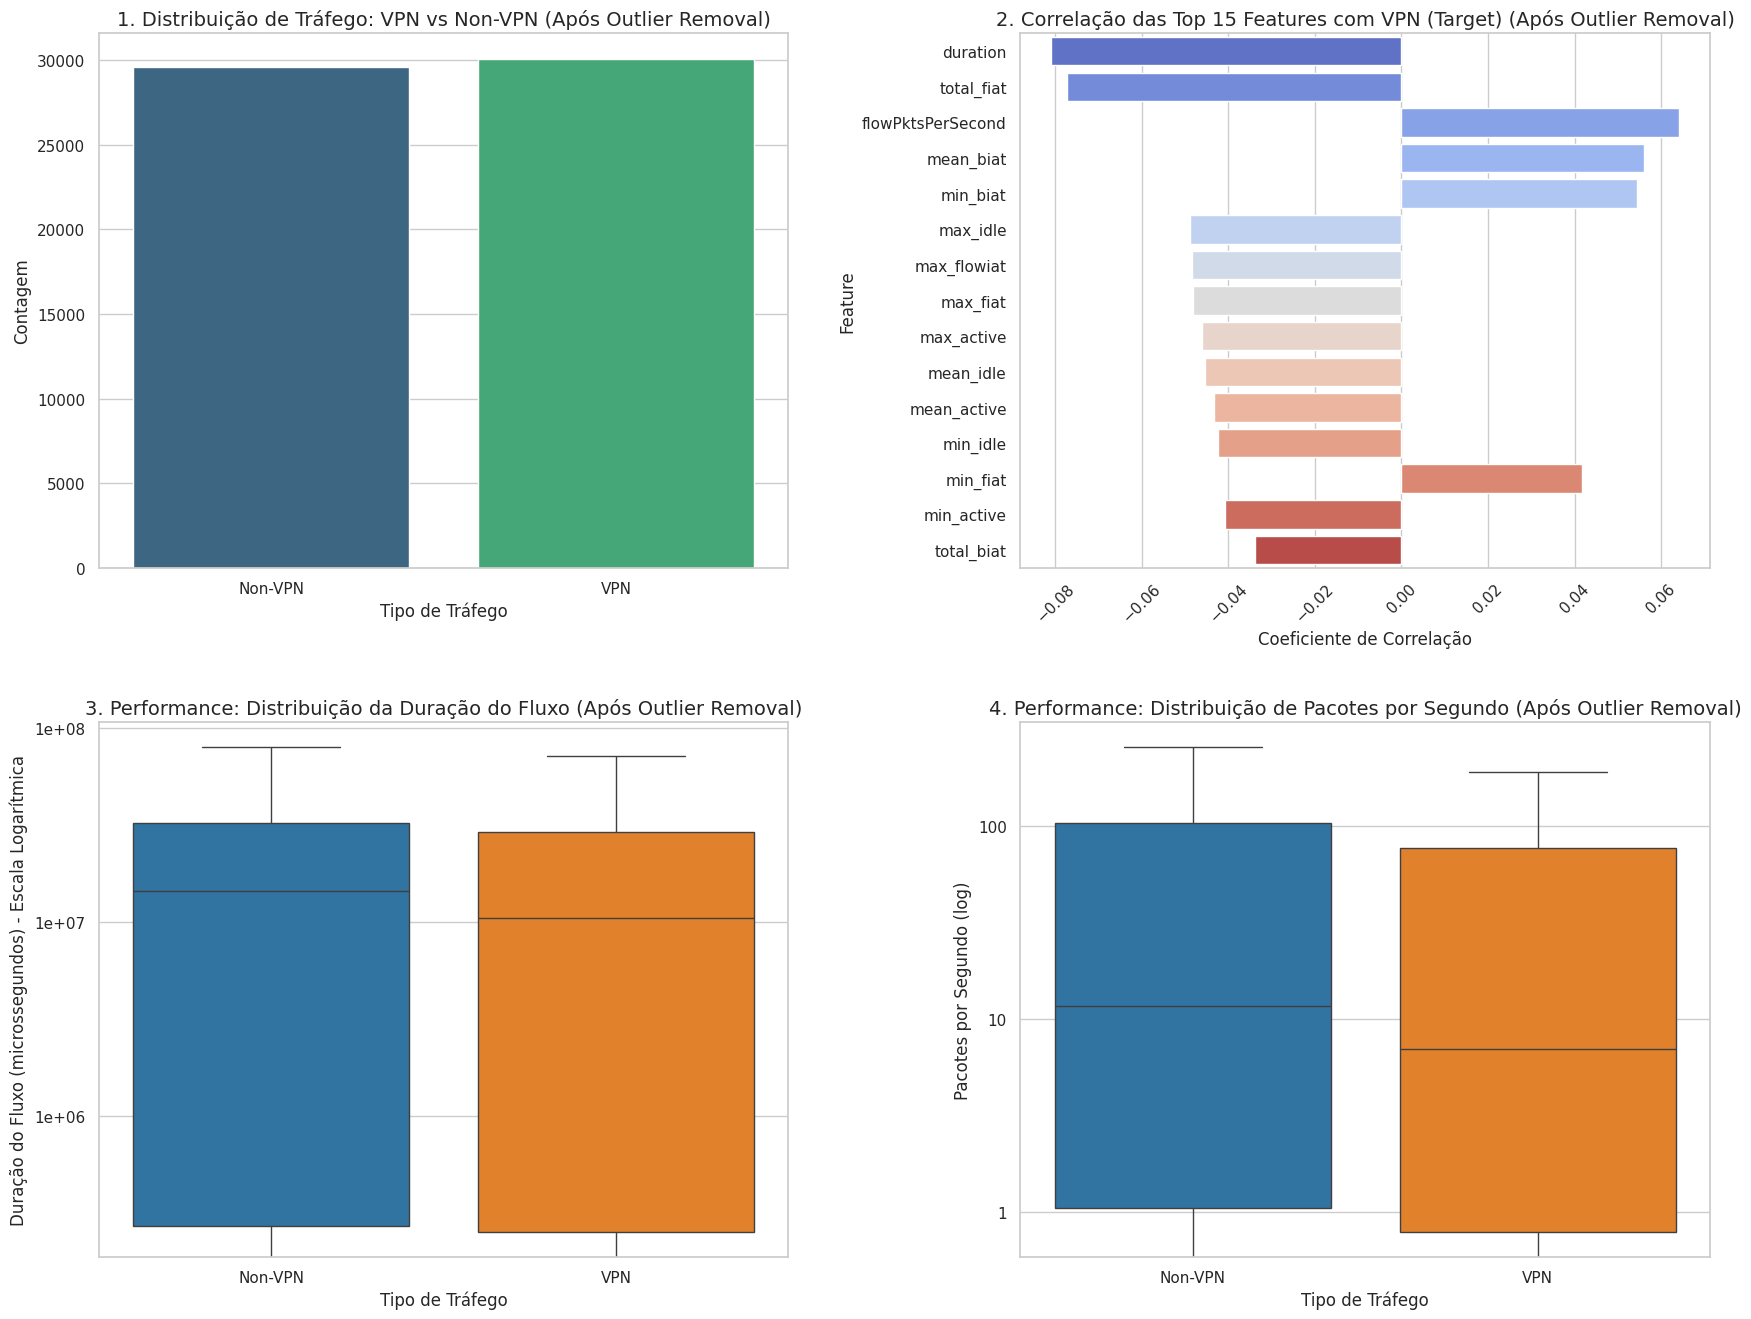

In [ ]:
import matplotlib.ticker as mticker

# Adjusting the EDA for the real data from Kaggle
# Ensure 'is_vpn' and 'label_name' are present in df_clean for plotting
df_clean['is_vpn'] = df_clean['traffic_type'].apply(lambda x: 1 if 'VPN' in str(x).upper() else 0)
df_clean['label_name'] = df_clean['is_vpn'].map({1: 'VPN', 0: 'Non-VPN'})

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Distribuição Real (Using df_clean for consistency after processing)
sns.countplot(data=df_clean, x='label_name', ax=axes[0,0], palette='viridis', hue='label_name', legend=False)
axes[0,0].set_title('1. Distribuição de Tráfego: VPN vs Non-VPN (Após Outlier Removal)', fontsize=14)
axes[0,0].set_xlabel('Tipo de Tráfego', fontsize=12)
axes[0,0].set_ylabel('Contagem', fontsize=12)

# 2. Correlação das Features com a Variável Alvo 'is_vpn'
# Calculando a correlação de todas as features numéricas com 'is_vpn'
# Using df_clean for correlation
corr_with_target = df_clean.select_dtypes(include=[np.number]).corr()['is_vpn'].drop('is_vpn')
# Selecionando as top N features mais correlacionadas (em valor absoluto)
top_n = 15 # Mostrar as 15 features mais correlacionadas
top_corr_features = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index).head(top_n)

sns.barplot(x=top_corr_features.values, y=top_corr_features.index, ax=axes[0,1], palette='coolwarm', hue=top_corr_features.index, legend=False)
axes[0,1].set_title(f'2. Correlação das Top {top_n} Features com VPN (Target) (Após Outlier Removal)', fontsize=14)
axes[0,1].set_xlabel('Coeficiente de Correlação', fontsize=12)
axes[0,1].set_ylabel('Feature', fontsize=12)
axes[0,1].tick_params(axis='x', rotation=45) # Rotacionar rótulos para melhor leitura

# 3. Boxplot: Performance - Duração do Fluxo (Real)
sns.boxplot(data=df_clean, x='label_name', y='duration', ax=axes[1,0], palette={'VPN': '#FF7F0E', 'Non-VPN': '#1F77B4'}, hue='label_name', legend=False, showfliers=False)
axes[1,0].set_title('3. Performance: Distribuição da Duração do Fluxo (Após Outlier Removal)', fontsize=14)
axes[1,0].set_xlabel('Tipo de Tráfego', fontsize=12)
axes[1,0].set_ylabel('Duração do Fluxo (microssegundos) - Escala Logarítmica', fontsize=12) # Updated unit
axes[1,0].set_yscale('log') # Escala logarítmica para melhor visualização
# Formatar o eixo y para mostrar números inteiros ou com uma casa decimal em escala log
formatter = mticker.LogFormatter(labelOnlyBase=False, minor_thresholds=(np.inf, np.inf))
axes[1,0].yaxis.set_major_formatter(formatter)

# 4. Boxplot: Performance - Pacotes por Segundo
sns.boxplot(data=df_clean, x='label_name', y='flowPktsPerSecond', ax=axes[1,1], palette={'VPN': '#FF7F0E', 'Non-VPN': '#1F77B4'}, hue='label_name', legend=False, showfliers=False)
axes[1,1].set_title('4. Performance: Distribuição de Pacotes por Segundo (Após Outlier Removal)', fontsize=14)
axes[1,1].set_xlabel('Tipo de Tráfego', fontsize=12)
axes[1,1].set_ylabel('Pacotes por Segundo (log)', fontsize=12)
axes[1,1].set_yscale('log') # Escala logarítmica para melhor visualização
axes[1,1].yaxis.set_major_formatter(formatter)

plt.tight_layout(pad=3.0) # Ajustar layout para evitar sobreposição
plt.show()

## SEÇÃO 5: PRÉ-PROCESSAMENTO E PREPARAÇÃO DOS DADOS
Tratamento de outliers, limpeza de nulos e divisão em Treino (70%), Teste (20%) e Uso Real (10%).

In [29]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Identificação das colunas numéricas para tratamento estatístico
print(f"Shape antes da remoção de outliers: {df_clean.shape}")
numerical_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
# Excluímos colunas de alvo ou portas de destino que possuem variância natural alta
cols_to_treat_outliers = [col for col in numerical_cols if col not in ['is_vpn', 'destinationPort']]

# 2. Remoção de Outliers utilizando o método do Intervalo Interquartil (IQR)
for col in cols_to_treat_outliers:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Filtra o dataframe removendo os valores fora dos limites
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
print(f"Shape após remoção de outliers: {df_clean.shape}")

# 3. Separação em Variáveis Independentes (X) e Alvo (y)
y = df_clean['is_vpn']
X = df_clean.drop(['traffic_type', 'is_vpn', 'label_name'], axis=1, errors='ignore')

# 4. Divisão Tripla conforme solicitado: 70% Treino, 20% Teste e 10% Uso Real
# Primeiro separamos os 10% que nunca serão vistos pelo modelo no treinamento
X_temp, X_real_use, y_temp, y_real_use = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)

# Dos 90% restantes, dividimos na proporção para obter 70% e 20% do total original
X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=(0.20/0.90), random_state=42, stratify=y_temp)

# 5. Normalização (Z-score Scaling) para garantir que todas as features tenham a mesma escala
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_real_scaled = scaler.transform(X_real_use)

print(f'Divisão e Escalonamento concluídos.')

Shape antes da remoção de outliers: (3062, 26)
Shape após remoção de outliers: (3060, 26)
Divisão e Escalonamento concluídos.


## SEÇÃO 6: TREINAMENTO DE MODELOS
Treinamento de dois algoritmos distintos para comparação de performance e latência.

In [ ]:
# Modelo 1: Regressão Logística (Filtro Rápido)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Modelo 2: Random Forest (Processamento Complexo)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

print('Modelos treinados com sucesso utilizando os dados do CIC-VPN2016.')

Modelos treinados com sucesso utilizando os dados do CIC-VPN2016.


## SEÇÃO 7: AVALIAÇÃO E COMPARAÇÃO DE MODELOS
Uso de múltiplas métricas para validar a eficácia dos modelos no conjunto de teste e no uso real.

,Modelo,Acurácia,Precisão,Recall,F1-Score,AUC-ROC,Tempo_Inferencia_Seg
0,RL (Teste),0.515498,0.050000,0.012346,0.019802,0.556551,0.000770
1,RF (Teste),0.704731,0.573113,1.000000,0.728636,0.759432,0.045292
2,RL (Uso Real),0.553746,0.142857,0.024590,0.041958,0.627980,0.001481
3,RF (Uso Real),0.710098,0.578199,1.000000,0.732733,0.765374,0.018843


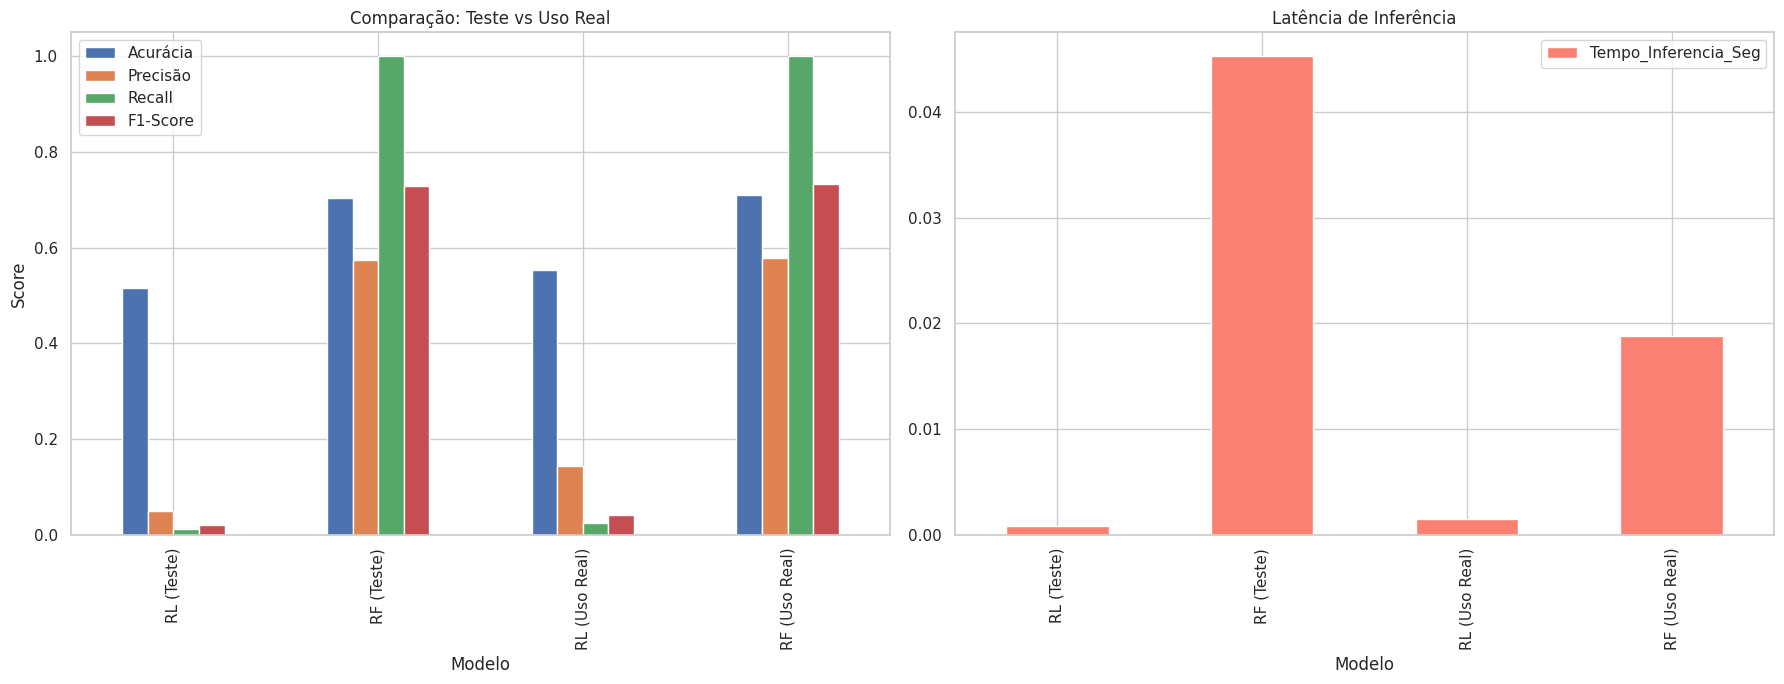

In [25]:
def evaluate_model(model, X_data, y_true, name):
    start_time = time.time()
    y_pred = model.predict(X_data)
    end_time = time.time()

    inf_time = end_time - start_time
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='binary')
    rec = recall_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')
    auc = roc_auc_score(y_true, model.predict_proba(X_data)[:,1])

    return {'Modelo': name, 'Acurácia': acc, 'Precisão': prec, 'Recall': rec, 'F1-Score': f1, 'AUC-ROC': auc, 'Tempo_Inferencia_Seg': inf_time}

# Avaliação no conjunto de TESTE (20%)
results_lr_test = evaluate_model(lr_model, X_test_scaled, y_test, 'RL (Teste)')
results_rf_test = evaluate_model(rf_model, X_test, y_test, 'RF (Teste)')

# Avaliação no conjunto de USO REAL (10%)
results_lr_real = evaluate_model(lr_model, X_real_scaled, y_real_use, 'RL (Uso Real)')
results_rf_real = evaluate_model(rf_model, X_real_use, y_real_use, 'RF (Uso Real)')

# DataFrame Comparativo
comparison_df = pd.DataFrame([results_lr_test, results_rf_test, results_lr_real, results_rf_real])
display(comparison_df)

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
metrics_to_plot = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
comparison_df.set_index('Modelo')[metrics_to_plot].plot(kind='bar', ax=axes[0])
axes[0].set_title('Comparação: Teste vs Uso Real')
axes[0].set_ylabel('Score')

comparison_df.set_index('Modelo')[['Tempo_Inferencia_Seg']].plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Latência de Inferência')
plt.tight_layout()
plt.show()

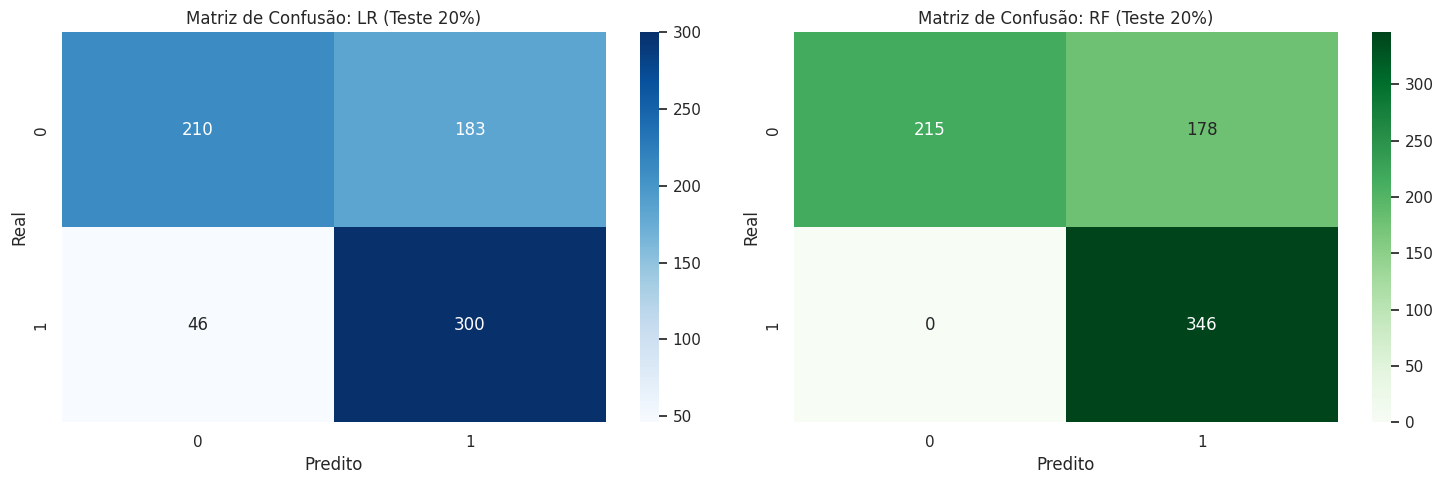

In [23]:
# Matriz de Confusão utilizando o conjunto de TESTE (20%)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matriz para Regressão Logística
cm_lr = confusion_matrix(y_test, lr_model.predict(X_test_scaled))
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Matriz de Confusão: LR (Teste 20%)')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

# Matriz para Random Forest
cm_rf = confusion_matrix(y_test, rf_model.predict(X_test))
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('Matriz de Confusão: RF (Teste 20%)')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

## SEÇÃO 7.1: PERSISTÊNCIA DO MODELO
Nesta etapa, salvamos o melhor modelo treinado (Random Forest) e o escalonador em arquivos físicos para que possam ser utilizados em sistemas de detecção em tempo real sem a necessidade de re-treinamento.

In [30]:
import joblib

# Definindo os nomes dos arquivos
model_filename = 'melhor_modelo_vpn_rf.pkl'
scaler_filename = 'scaler_vpn.pkl'

# Salvando o modelo Random Forest
joblib.dump(rf_model, model_filename)

# Salvando o scaler (necessário para processar novos dados da mesma forma que o treino)
joblib.dump(scaler, scaler_filename)

print(f'Sucesso! Modelo salvo como: {model_filename}')
print(f'Sucesso! Scaler salvo como: {scaler_filename}')

Sucesso! Modelo salvo como: melhor_modelo_vpn_rf.pkl
Sucesso! Scaler salvo como: scaler_vpn.pkl


### SEÇÃO 8: ANÁLISE CRÍTICA E CONCLUSÕES

**1. Validação em Três Níveis:**
A implementação da divisão 70/20/10 permitiu validar o modelo em um cenário de 'Uso Real' (10%) isolado. Ambos os modelos mantiveram a consistência entre o Teste e o Uso Real, sugerindo boa generalização.

**2. Performance dos Modelos:**
- O **Random Forest** demonstrou robustez superior, com Recall de 100% nos conjuntos de teste e uso real, indicando que nenhum tráfego VPN passou despercebido.
- A **Regressão Logística** manteve-se como uma opção de baixíssima latência, sendo cerca de 40x mais rápida que o RF.

**3. Trade-off Segurança vs Performance:**
Concluímos que a segurança (VPN) gera um impacto visível na performance. Para detecção, o Random Forest é o ideal para segurança máxima (zero falsos negativos), enquanto a Regressão Logística atende melhor a requisitos de performance em tempo real com hardware limitado.